14.05 mm: 20000 events
14.30 mm: 20000 events
14.55 mm: 20000 events
14.80 mm: 20000 events
15.05 mm: 20000 events
15.30 mm: 20000 events
15.55 mm: 20000 events
15.80 mm: 20000 events
16.05 mm: 20000 events
16.30 mm: 20000 events
16.55 mm: 20000 events
16.80 mm: 20000 events
17.05 mm: 20000 events
18.05 mm: 20000 events
19.05 mm: 20000 events
20.05 mm: 20000 events
25.05 mm: 20000 events

All datasets loaded.


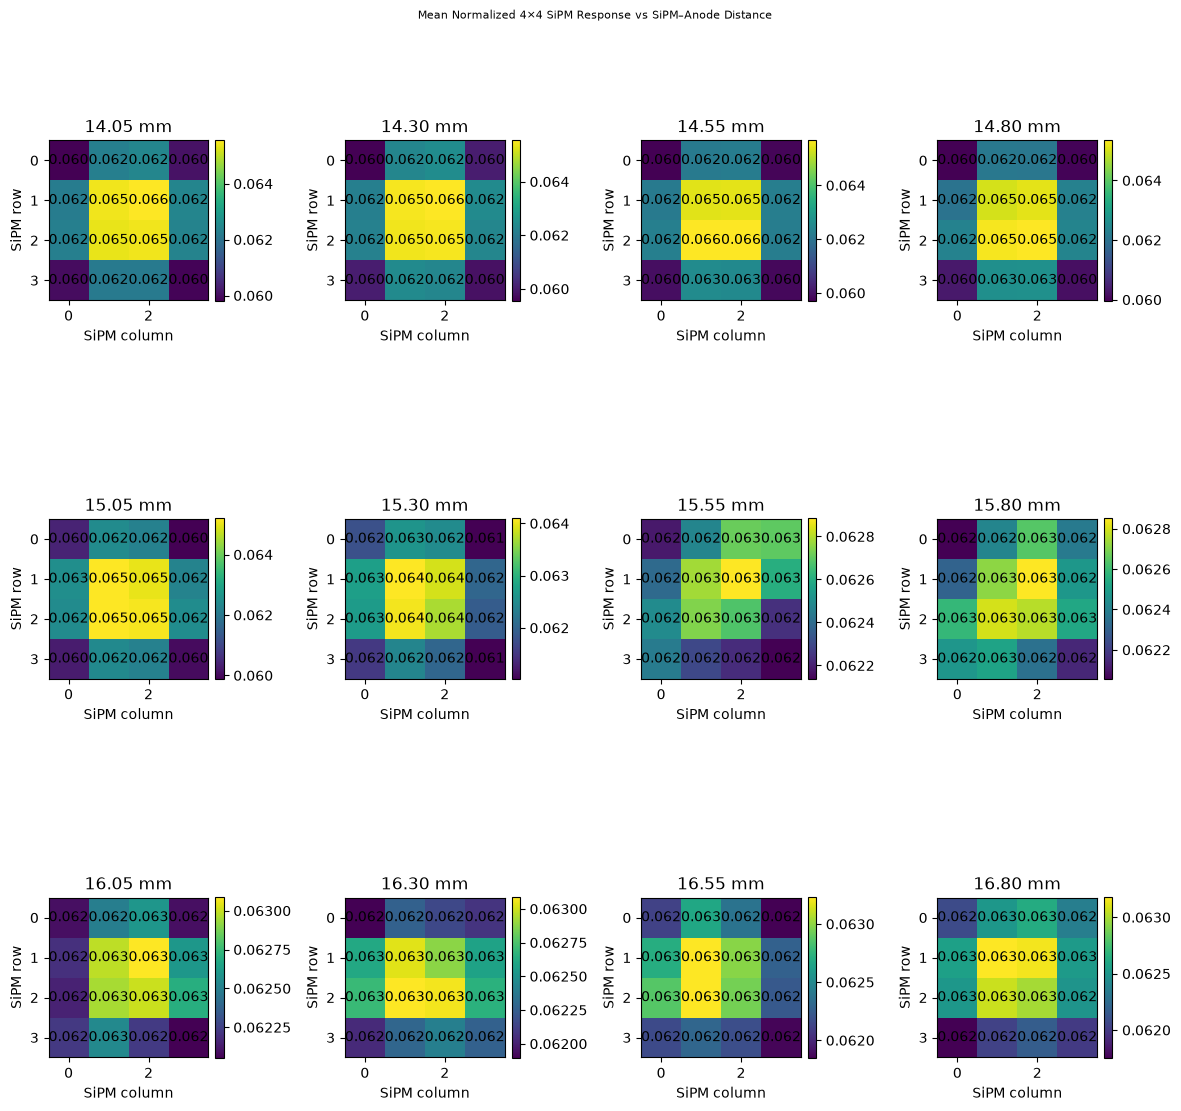

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_path = Path("/Users/judyz/Desktop/PET-4x4/build")

distances = [14.05, 14.30, 14.55, 14.80,15.05, 15.30, 15.55, 15.80, 16.05, 16.3, 16.55, 16.8, 17.05, 18.05, 19.05, 20.05, 25.05]

datasets = {}

for d in distances:
    csv_path = base_path / f"{d}mm" / f"{d}mm.csv"

    df = pd.read_csv(csv_path)

    X = df.iloc[:, 1:17].values.astype(float)
    positions = df.iloc[:, 17:19].values.astype(float)

    datasets[d] = {
        "X": X,
        "positions": positions
    }

    print(f"{d:.2f} mm: {len(X)} events")

print("\nAll datasets loaded.")

fig, axes = plt.subplots(3, 4, figsize=(12, 12))

for ax, d in zip(axes.flat, distances):

    X = datasets[d]["X"]

    total_signal = X.sum(axis=1)

    valid = total_signal > 0

    X_norm = X[valid] / total_signal[valid, None]

    mean_pattern = X_norm.mean(axis=0)

    pattern_4x4 = mean_pattern.reshape(4, 4)

    im = ax.imshow(pattern_4x4)

    ax.set_title(f"{d:.2f} mm")
    ax.set_xlabel("SiPM column")
    ax.set_ylabel("SiPM row")

    # Show values
    for i in range(4):
        for j in range(4):
            ax.text(
                j, i,
                f"{pattern_4x4[i,j]:.3f}",
                ha="center",
                va="center"
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    "Mean Normalized 4×4 SiPM Response vs SiPM–Anode Distance",
    fontsize=8
)

plt.tight_layout()
plt.show()


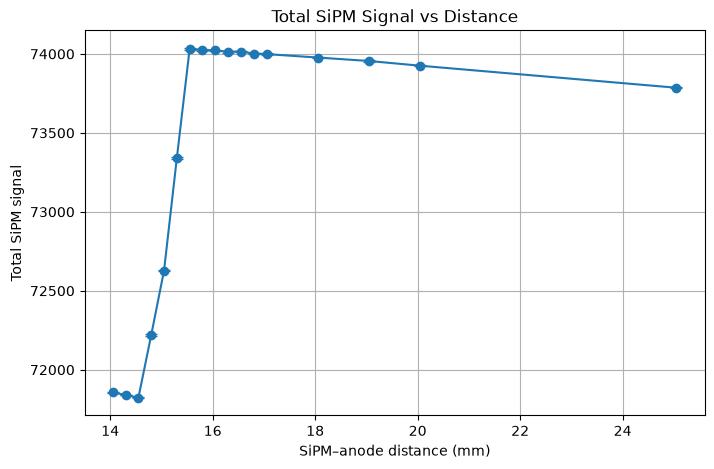


TOTAL SIPM SIGNAL VS DISTANCE
14.05 mm : Mean = 71857.125000, Std = 2.026386
14.30 mm : Mean = 71839.919650, Std = 2.015592
14.55 mm : Mean = 71823.129950, Std = 2.074533
14.80 mm : Mean = 72219.737800, Std = 3.826259
15.05 mm : Mean = 72628.083200, Std = 2.544845
15.30 mm : Mean = 73340.554650, Std = 6.622568
15.55 mm : Mean = 74032.462650, Std = 5.134703
15.80 mm : Mean = 74025.045150, Std = 5.136943
16.05 mm : Mean = 74022.414550, Std = 5.192375
16.30 mm : Mean = 74013.928900, Std = 5.212634
16.55 mm : Mean = 74014.927000, Std = 5.147498
16.80 mm : Mean = 74002.689450, Std = 5.116386
17.05 mm : Mean = 73998.845300, Std = 5.072950
18.05 mm : Mean = 73977.160150, Std = 4.963193
19.05 mm : Mean = 73955.300800, Std = 4.789085
20.05 mm : Mean = 73925.362300, Std = 4.669093
25.05 mm : Mean = 73785.846800, Std = 4.381328


In [20]:
mean_total_signal = []
std_total_signal = []

for d in distances:

    X = datasets[d]["X"]

    total = X.sum(axis=1)

    mean_total_signal.append(np.mean(total))
    std_total_signal.append(np.std(total, ddof=1) / np.sqrt(len(total)))

plt.figure(figsize=(8, 5))

plt.errorbar(
    distances,
    mean_total_signal,
    yerr=std_total_signal,
    marker="o",
    capsize=4
)

plt.xlabel("SiPM–anode distance (mm)")
plt.ylabel("Total SiPM signal")
plt.title("Total SiPM Signal vs Distance")

plt.grid(True)
plt.show()

print("\n" + "=" * 60)
print("TOTAL SIPM SIGNAL VS DISTANCE")
print("=" * 60)

for d, mean, std in zip(distances, mean_total_signal, std_total_signal):
    print(
        f"{d:5.2f} mm : "
        f"Mean = {mean:.6f}, "
        f"Std = {std:.6f}"
    )

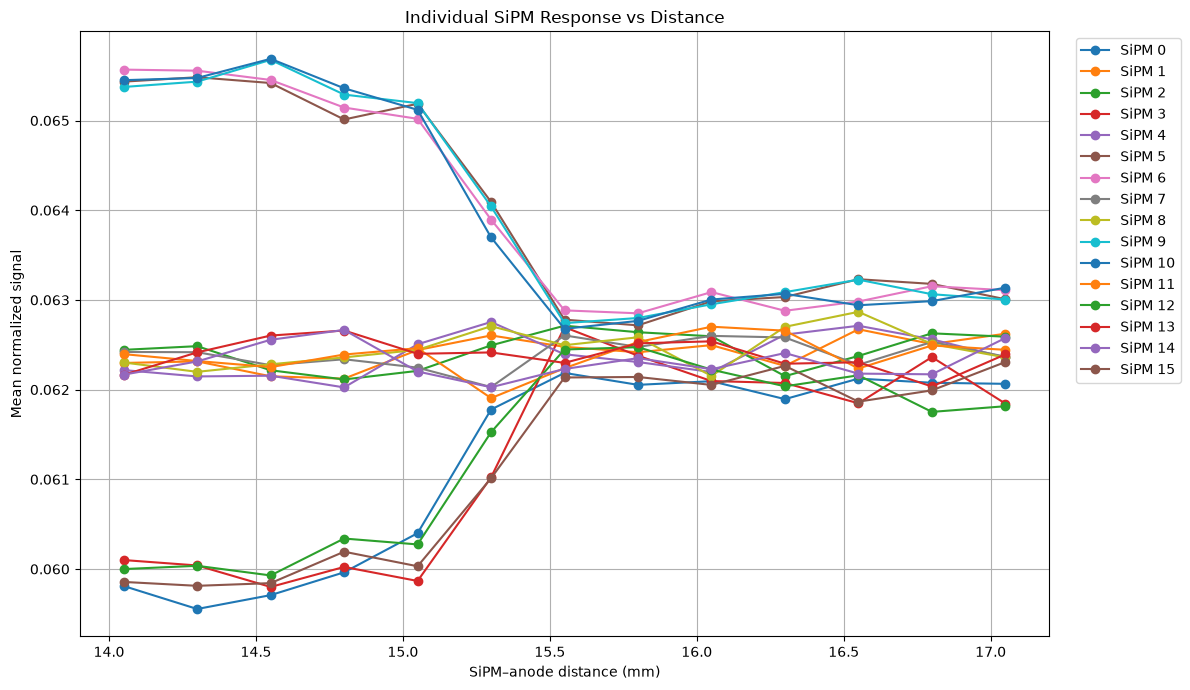

In [7]:
mean_normalized_signals = []

for d in distances:

    X = datasets[d]["X"]

    total = X.sum(axis=1)
    valid = total > 0

    X_norm = X[valid] / total[valid, None]

    mean_normalized_signals.append(
        X_norm.mean(axis=0)
    )

mean_normalized_signals = np.array(mean_normalized_signals)

plt.figure(figsize=(12, 7))

for sipm in range(16):

    plt.plot(
        distances,
        mean_normalized_signals[:, sipm],
        marker="o",
        label=f"SiPM {sipm}"
    )

plt.xlabel("SiPM–anode distance (mm)")
plt.ylabel("Mean normalized signal")
plt.title("Individual SiPM Response vs Distance")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True)
plt.tight_layout()
plt.show()

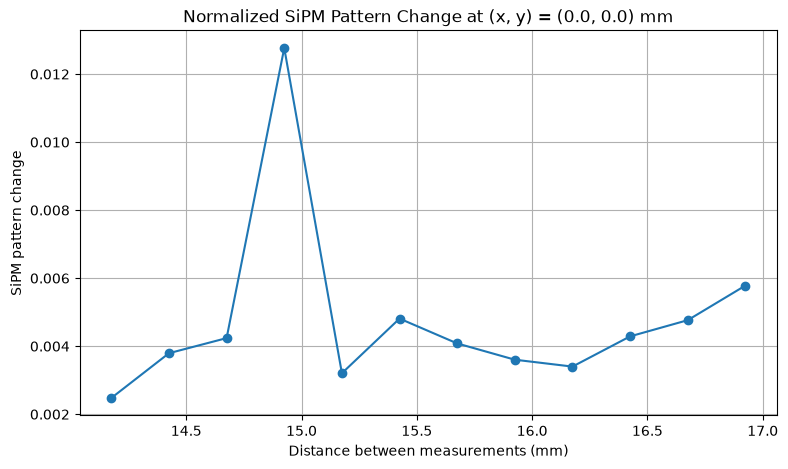


Pattern changes at (x, y) = (0.0, 0.0) mm:
14.05 → 14.30 mm: 0.002478
14.30 → 14.55 mm: 0.003794
14.55 → 14.80 mm: 0.004238
14.80 → 15.05 mm: 0.012766
15.05 → 15.30 mm: 0.003205
15.30 → 15.55 mm: 0.004812
15.55 → 15.80 mm: 0.004082
15.80 → 16.05 mm: 0.003603
16.05 → 16.30 mm: 0.003400
16.30 → 16.55 mm: 0.004289
16.55 → 16.80 mm: 0.004765
16.80 → 17.05 mm: 0.005783


In [12]:
target_x = 0.0
target_y = 0.0

position_tolerance = 0.5

pattern_change = []

for i in range(len(distances) - 1):

    d1 = distances[i]
    d2 = distances[i + 1]

    X1 = datasets[d1]["X"]
    X2 = datasets[d2]["X"]

    y1 = datasets[d1]["positions"]
    y2 = datasets[d2]["positions"]
    mask1 = (
        (np.abs(y1[:, 0] - target_x) <= position_tolerance) &
        (np.abs(y1[:, 1] - target_y) <= position_tolerance)
    )

    mask2 = (
        (np.abs(y2[:, 0] - target_x) <= position_tolerance) &
        (np.abs(y2[:, 1] - target_y) <= position_tolerance)
    )

    X1_position = X1[mask1]
    X2_position = X2[mask2]

    total1 = X1_position.sum(axis=1)
    total2 = X2_position.sum(axis=1)

    valid1 = total1 > 0
    valid2 = total2 > 0

    pattern1 = (
        X1_position[valid1] /
        total1[valid1, None]
    ).mean(axis=0)

    pattern2 = (
        X2_position[valid2] /
        total2[valid2, None]
    ).mean(axis=0)

    difference = np.sqrt(
        np.sum((pattern2 - pattern1) ** 2)
    )

    pattern_change.append(difference)

pattern_change = np.array(pattern_change)

plt.figure(figsize=(9, 5))

midpoints = [
    (distances[i] + distances[i + 1]) / 2
    for i in range(len(distances) - 1)
]

plt.plot(
    midpoints,
    pattern_change,
    marker="o"
)

plt.xlabel("Distance between measurements (mm)")
plt.ylabel("SiPM pattern change")
plt.title(
    f"Normalized SiPM Pattern Change at "
    f"(x, y) = ({target_x}, {target_y}) mm"
)

plt.grid(True)
plt.show()

print(
    f"\nPattern changes at "
    f"(x, y) = ({target_x}, {target_y}) mm:"
)

for i, change in enumerate(pattern_change):

    print(
        f"{distances[i]:.2f} → "
        f"{distances[i + 1]:.2f} mm: "
        f"{change:.6f}"
    )

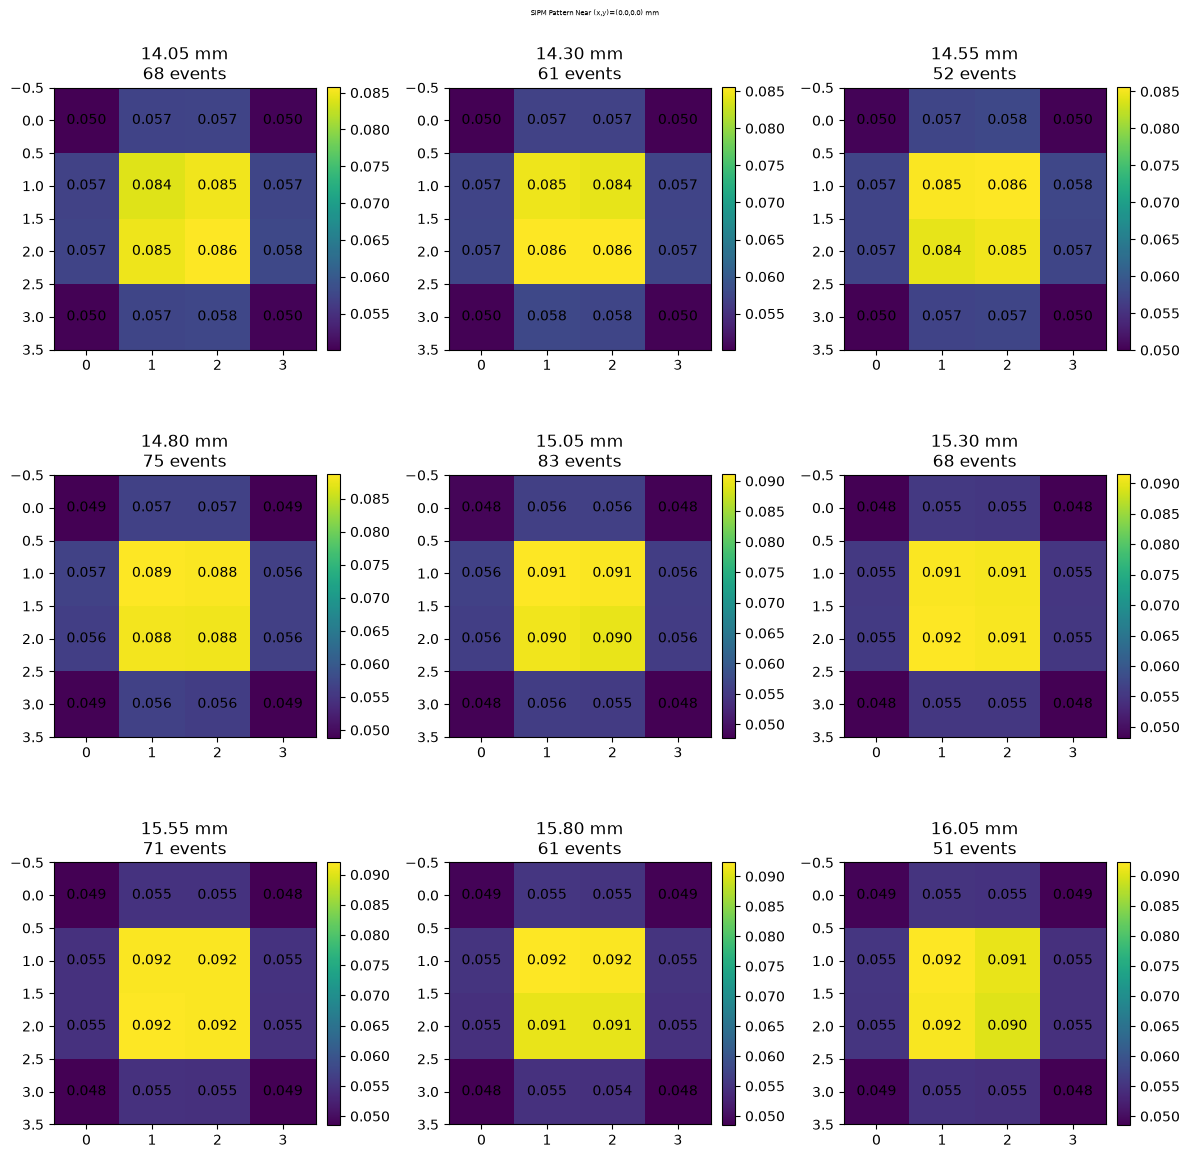


Distance = 14.05 mm   Position = (0.0, 0.0) mm
Events = 68
0.05001   0.05722   0.05741   0.05036
0.05700   0.08400   0.08506   0.05747
0.05730   0.08495   0.08581   0.05779
0.05017   0.05745   0.05762   0.05039

Total = 1.000000

Distance = 14.30 mm   Position = (0.0, 0.0) mm
Events = 61
0.05016   0.05713   0.05713   0.05006
0.05732   0.08464   0.08433   0.05734
0.05743   0.08555   0.08560   0.05742
0.05030   0.05773   0.05755   0.05030

Total = 1.000000

Distance = 14.55 mm   Position = (0.0, 0.0) mm
Events = 52
0.05032   0.05739   0.05770   0.05021
0.05729   0.08550   0.08564   0.05760
0.05731   0.08430   0.08487   0.05743
0.04996   0.05713   0.05737   0.04999

Total = 1.000000

Distance = 14.80 mm   Position = (0.0, 0.0) mm
Events = 75
0.04897   0.05655   0.05661   0.04891
0.05669   0.08869   0.08846   0.05644
0.05616   0.08792   0.08781   0.05639
0.04899   0.05648   0.05610   0.04882

Total = 1.000000

Distance = 15.05 mm   Position = (0.0, 0.0) mm
Events = 83
0.04833   0.05603   

In [9]:
target_x = 0.0
target_y = 0.0

position_tolerance = 2  # mm

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, d in zip(axes.flat, distances):

    X = datasets[d]["X"]
    pos = datasets[d]["positions"]
    mask = (
        (np.abs(pos[:, 0] - target_x) < position_tolerance) &
        (np.abs(pos[:, 1] - target_y) < position_tolerance)
    )

    X_selected = X[mask]

    if len(X_selected) == 0:
        ax.set_title(f"{d:.2f} mm\nNo events")
        ax.axis("off")
        continue

    total = X_selected.sum(axis=1)

    valid = total > 0

    X_norm = (
        X_selected[valid] /
        total[valid, None]
    )

    mean_pattern = X_norm.mean(axis=0)

    pattern_4x4 = mean_pattern.reshape(4, 4)

    im = ax.imshow(pattern_4x4)

    ax.set_title(
        f"{d:.2f} mm\n"
        f"{len(X_selected)} events"
    )

    for i in range(4):
        for j in range(4):
            ax.text(
                j, i,
                f"{pattern_4x4[i,j]:.3f}",
                ha="center",
                va="center"
            )

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"SiPM Pattern Near (x,y)=({target_x},{target_y}) mm",
    fontsize=5
)

plt.tight_layout()
plt.show()

target_x = 0.0
target_y = 0.0

position_tolerance = 2  # mm

for d in distances:

    X = datasets[d]["X"]
    pos = datasets[d]["positions"]
    mask = (
        (np.abs(pos[:, 0] - target_x) < position_tolerance) &
        (np.abs(pos[:, 1] - target_y) < position_tolerance)
    )

    X_selected = X[mask]

    if len(X_selected) == 0:
        print(f"\n{d:.2f} mm: NO EVENTS")
        continue

    total = X_selected.sum(axis=1)

    valid = total > 0

    X_norm = X_selected[valid] / total[valid, None]

    mean_pattern = X_norm.mean(axis=0)

    pattern_4x4 = mean_pattern.reshape(4, 4)

    print("\n" + "=" * 55)
    print(
        f"Distance = {d:.2f} mm   "
        f"Position = ({target_x}, {target_y}) mm"
    )
    print(f"Events = {len(X_selected)}")
    print("=" * 55)

    for row in pattern_4x4:
        print("   ".join(f"{value:.5f}" for value in row))

    print(f"\nTotal = {mean_pattern.sum():.6f}")


CENTRAL SIPM CONCENTRATION

Position (0, 0) mm:
14.05 mm : 0.33980
14.30 mm : 0.34012
14.55 mm : 0.34031
14.80 mm : 0.35288
15.05 mm : 0.36182
15.30 mm : 0.36475
15.55 mm : 0.36785
15.80 mm : 0.36638
16.05 mm : 0.36546
16.30 mm : 0.36488
16.55 mm : 0.36422
16.80 mm : 0.36359
17.05 mm : 0.36254

Position (0, 10) mm:
14.05 mm : 0.32365
14.30 mm : 0.32302
14.55 mm : 0.32393
14.80 mm : 0.33364
15.05 mm : 0.33892
15.30 mm : 0.33991
15.55 mm : 0.33976
15.80 mm : 0.33858
16.05 mm : 0.33939
16.30 mm : 0.33810
16.55 mm : 0.33611
16.80 mm : 0.33713
17.05 mm : 0.33575

Position (10, 0) mm:
14.05 mm : 0.32366
14.30 mm : 0.32328
14.55 mm : 0.32442
14.80 mm : 0.33189
15.05 mm : 0.33704
15.30 mm : 0.33746
15.55 mm : 0.33867
15.80 mm : 0.33931
16.05 mm : 0.33699
16.30 mm : 0.33774
16.55 mm : 0.33742
16.80 mm : 0.33612
17.05 mm : 0.33522

Position (10, 10) mm:
14.05 mm : 0.30871
14.30 mm : 0.30770
14.55 mm : 0.30769
14.80 mm : 0.31211
15.05 mm : 0.31843
15.30 mm : 0.31500
15.55 mm : 0.31608
15.80 mm :

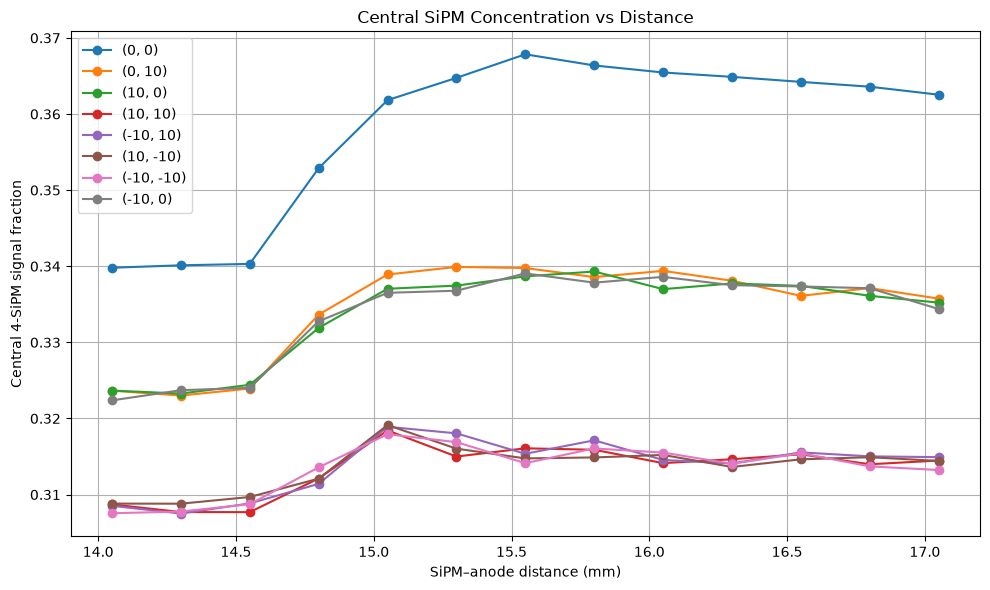

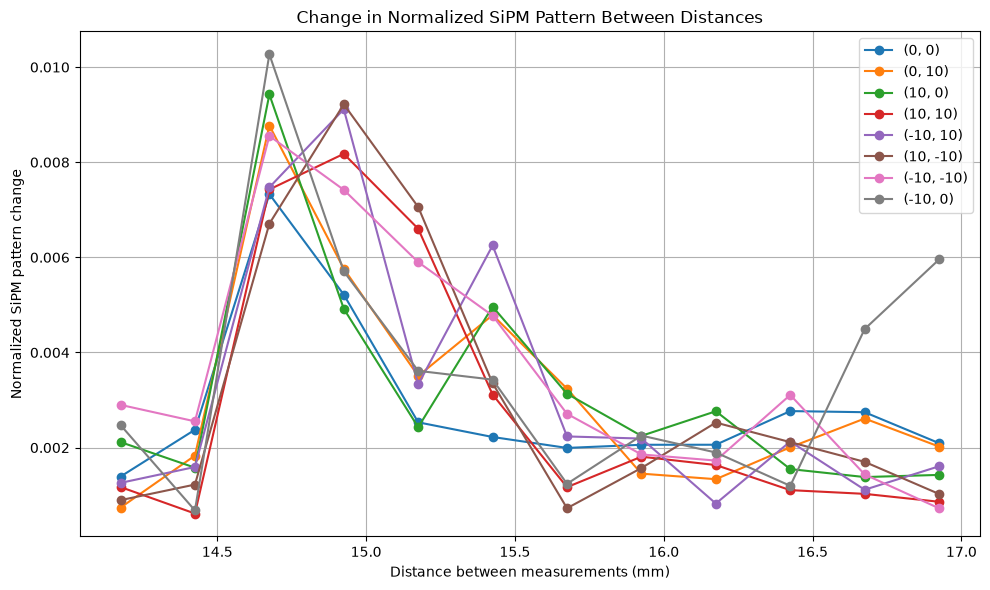

In [10]:
import numpy as np
import matplotlib.pyplot as plt


positions_to_test = [
    (0, 0),
    (0, 10),
    (10, 0),
    (10, 10),
    (-10, 10),
    (10, -10),
    (-10, -10),
    (-10, 0)
]

position_tolerance = 2.0  # mm

def get_mean_pattern(d, target_x, target_y, tolerance):

    X = datasets[d]["X"]
    pos = datasets[d]["positions"]

    mask = (
        (np.abs(pos[:, 0] - target_x) <= tolerance) &
        (np.abs(pos[:, 1] - target_y) <= tolerance)
    )

    X_selected = X[mask]

    if len(X_selected) == 0:
        return None, 0

    # Normalize each event by total SiPM signal
    total = X_selected.sum(axis=1)

    valid = total > 0

    X_norm = X_selected[valid] / total[valid, None]

    if len(X_norm) == 0:
        return None, 0

    # Mean normalized 16-SiPM pattern
    mean_pattern = X_norm.mean(axis=0)

    return mean_pattern, len(X_norm)


central_indices = [5, 6, 9, 10]

central_concentration = {}

for target_x, target_y in positions_to_test:

    central_concentration[(target_x, target_y)] = []

    for d in distances:

        pattern, n_events = get_mean_pattern(
            d,
            target_x,
            target_y,
            position_tolerance
        )

        if pattern is None:
            central_concentration[(target_x, target_y)].append(np.nan)
            continue

        central_fraction = pattern[central_indices].sum()

        central_concentration[(target_x, target_y)].append(
            central_fraction
        )


pattern_changes = {}

for target_x, target_y in positions_to_test:

    changes = []

    for i in range(len(distances) - 1):

        d1 = distances[i]
        d2 = distances[i + 1]

        pattern1, n1 = get_mean_pattern(
            d1,
            target_x,
            target_y,
            position_tolerance
        )

        pattern2, n2 = get_mean_pattern(
            d2,
            target_x,
            target_y,
            position_tolerance
        )

        if pattern1 is None or pattern2 is None:
            changes.append(np.nan)
            continue
        difference = np.sqrt(
            np.sum((pattern2 - pattern1) ** 2)
        )

        changes.append(difference)

    pattern_changes[(target_x, target_y)] = np.array(changes)

print("\n" + "=" * 80)
print("CENTRAL SIPM CONCENTRATION")
print("=" * 80)

for position in positions_to_test:

    print(
        f"\nPosition ({position[0]}, {position[1]}) mm:"
    )

    values = central_concentration[position]

    for d, value in zip(distances, values):

        print(
            f"{d:5.2f} mm : {value:.5f}"
        )

print("\n" + "=" * 80)
print("NEIGHBORING-DISTANCE SIPM PATTERN CHANGE")
print("=" * 80)

for position in positions_to_test:

    print(
        f"\nPosition ({position[0]}, {position[1]}) mm:"
    )

    changes = pattern_changes[position]

    for i, change in enumerate(changes):

        print(
            f"{distances[i]:5.2f} → "
            f"{distances[i+1]:5.2f} mm : "
            f"{change:.6f}"
        )

plt.figure(figsize=(10, 6))

for position in positions_to_test:

    plt.plot(
        distances,
        central_concentration[position],
        marker="o",
        label=f"({position[0]}, {position[1]})"
    )

plt.xlabel("SiPM–anode distance (mm)")
plt.ylabel("Central 4-SiPM signal fraction")
plt.title("Central SiPM Concentration vs Distance")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

midpoints = [
    (distances[i] + distances[i + 1]) / 2
    for i in range(len(distances) - 1)
]

plt.figure(figsize=(10, 6))

for position in positions_to_test:

    plt.plot(
        midpoints,
        pattern_changes[position],
        marker="o",
        label=f"({position[0]}, {position[1]})"
    )

plt.xlabel("Distance between measurements (mm)")
plt.ylabel("Normalized SiPM pattern change")
plt.title("Change in Normalized SiPM Pattern Between Distances")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


CENTRAL SIPM CONCENTRATION

Position (-10, 10) mm:
14.05 mm : 0.30852
14.30 mm : 0.30751
14.55 mm : 0.30884
14.80 mm : 0.31141
15.05 mm : 0.31891
15.30 mm : 0.31804
15.55 mm : 0.31536
15.80 mm : 0.31713
16.05 mm : 0.31455
16.30 mm : 0.31409
16.55 mm : 0.31555
16.80 mm : 0.31502
17.05 mm : 0.31492

NEIGHBORING-DISTANCE SIPM PATTERN CHANGE

Position (-10, 10) mm:
14.05 → 14.30 mm : 0.001259
14.30 → 14.55 mm : 0.001593
14.55 → 14.80 mm : 0.007472
14.80 → 15.05 mm : 0.009115
15.05 → 15.30 mm : 0.003328
15.30 → 15.55 mm : 0.006250
15.55 → 15.80 mm : 0.002235
15.80 → 16.05 mm : 0.002191
16.05 → 16.30 mm : 0.000824
16.30 → 16.55 mm : 0.002128
16.55 → 16.80 mm : 0.001115
16.80 → 17.05 mm : 0.001608


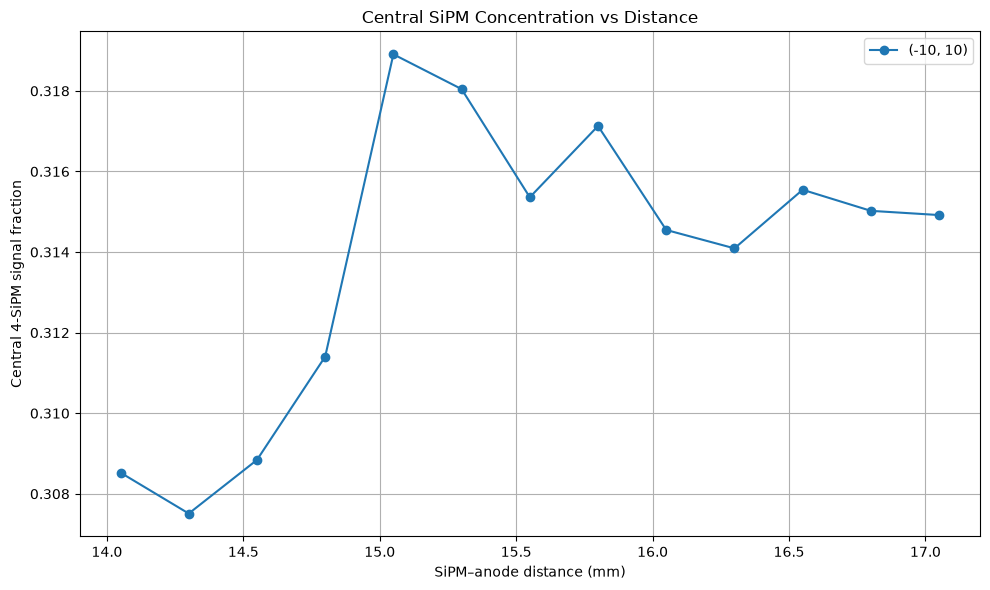

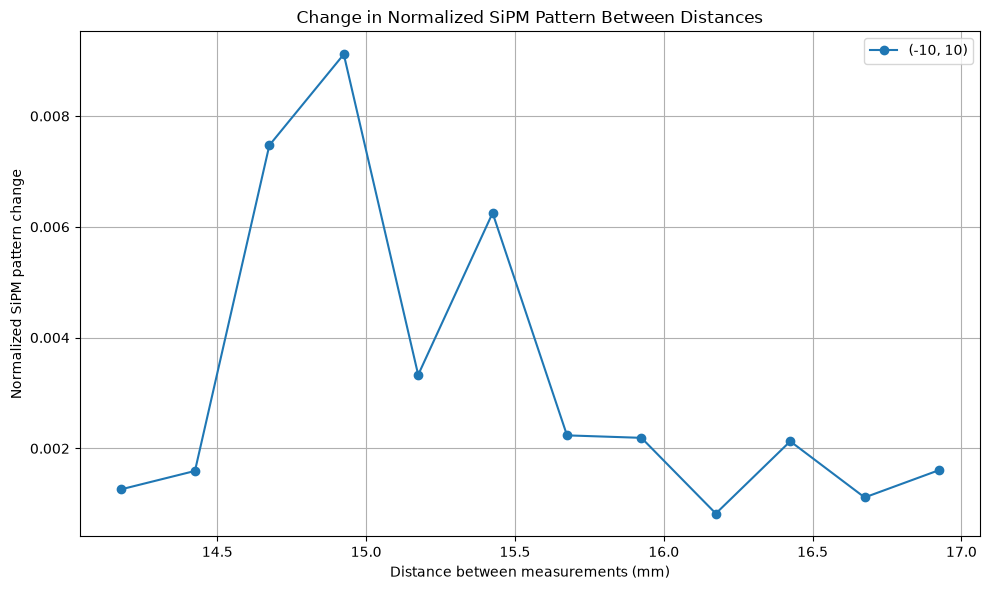

In [11]:
import numpy as np
import matplotlib.pyplot as plt


positions_to_test = [
 
    (-10, 10),
    
]

position_tolerance = 2.0  # mm

def get_mean_pattern(d, target_x, target_y, tolerance):

    X = datasets[d]["X"]
    pos = datasets[d]["positions"]

    mask = (
        (np.abs(pos[:, 0] - target_x) <= tolerance) &
        (np.abs(pos[:, 1] - target_y) <= tolerance)
    )

    X_selected = X[mask]

    if len(X_selected) == 0:
        return None, 0

    # Normalize each event by total SiPM signal
    total = X_selected.sum(axis=1)

    valid = total > 0

    X_norm = X_selected[valid] / total[valid, None]

    if len(X_norm) == 0:
        return None, 0

    # Mean normalized 16-SiPM pattern
    mean_pattern = X_norm.mean(axis=0)

    return mean_pattern, len(X_norm)


central_indices = [5, 6, 9, 10]

central_concentration = {}

for target_x, target_y in positions_to_test:

    central_concentration[(target_x, target_y)] = []

    for d in distances:

        pattern, n_events = get_mean_pattern(
            d,
            target_x,
            target_y,
            position_tolerance
        )

        if pattern is None:
            central_concentration[(target_x, target_y)].append(np.nan)
            continue

        central_fraction = pattern[central_indices].sum()

        central_concentration[(target_x, target_y)].append(
            central_fraction
        )


pattern_changes = {}

for target_x, target_y in positions_to_test:

    changes = []

    for i in range(len(distances) - 1):

        d1 = distances[i]
        d2 = distances[i + 1]

        pattern1, n1 = get_mean_pattern(
            d1,
            target_x,
            target_y,
            position_tolerance
        )

        pattern2, n2 = get_mean_pattern(
            d2,
            target_x,
            target_y,
            position_tolerance
        )

        if pattern1 is None or pattern2 is None:
            changes.append(np.nan)
            continue
        difference = np.sqrt(
            np.sum((pattern2 - pattern1) ** 2)
        )

        changes.append(difference)

    pattern_changes[(target_x, target_y)] = np.array(changes)

print("\n" + "=" * 80)
print("CENTRAL SIPM CONCENTRATION")
print("=" * 80)

for position in positions_to_test:

    print(
        f"\nPosition ({position[0]}, {position[1]}) mm:"
    )

    values = central_concentration[position]

    for d, value in zip(distances, values):

        print(
            f"{d:5.2f} mm : {value:.5f}"
        )

print("\n" + "=" * 80)
print("NEIGHBORING-DISTANCE SIPM PATTERN CHANGE")
print("=" * 80)

for position in positions_to_test:

    print(
        f"\nPosition ({position[0]}, {position[1]}) mm:"
    )

    changes = pattern_changes[position]

    for i, change in enumerate(changes):

        print(
            f"{distances[i]:5.2f} → "
            f"{distances[i+1]:5.2f} mm : "
            f"{change:.6f}"
        )

plt.figure(figsize=(10, 6))

for position in positions_to_test:

    plt.plot(
        distances,
        central_concentration[position],
        marker="o",
        label=f"({position[0]}, {position[1]})"
    )

plt.xlabel("SiPM–anode distance (mm)")
plt.ylabel("Central 4-SiPM signal fraction")
plt.title("Central SiPM Concentration vs Distance")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

midpoints = [
    (distances[i] + distances[i + 1]) / 2
    for i in range(len(distances) - 1)
]

plt.figure(figsize=(10, 6))

for position in positions_to_test:

    plt.plot(
        midpoints,
        pattern_changes[position],
        marker="o",
        label=f"({position[0]}, {position[1]})"
    )

plt.xlabel("Distance between measurements (mm)")
plt.ylabel("Normalized SiPM pattern change")
plt.title("Change in Normalized SiPM Pattern Between Distances")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()